In [ ]:
!sudo apt update
!sudo apt install -y tesseract-ocr
!pip install pytesseract pillow opencv-python-headless

print("✅ Tesseract and Python libraries installed.")

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,389 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,926 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-

# Import Modules

In [ ]:
import pytesseract
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import display
import os

# Point pytesseract to the Tesseract executable (default location in Colab)
pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

print("✅ Modules imported.")

✅ Modules imported.


# Define Transformation Functions

In [ ]:
# All functions take a PIL Image and return a transformed PIL Image.

def rotate_image(img, angle=5):
    """Rotate image by given angle (degrees)."""
    return img.rotate(angle, expand=True, fillcolor=(255,255,255))

def skew_image(img, shear=0.2):
    """Apply horizontal shear (skew)."""
    # Convert PIL to array for OpenCV
    arr = np.array(img)
    h, w = arr.shape[:2]
    # Shear matrix: x' = x + shear * y, y' = y
    # We'll use OpenCV's warpAffine
    M = np.float32([[1, shear, 0], [0, 1, 0]])
    new_w = int(w + abs(shear) * h)
    sheared = cv2.warpAffine(arr, M, (new_w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(sheared)

def blur_image(img, radius=2):
    """Apply Gaussian blur."""
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def add_noise(img, intensity=25):
    """Add random Gaussian noise."""
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, intensity, arr.shape)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def adjust_brightness(img, factor=1.5):
    """Change brightness (factor >1 brighter, <1 darker)."""
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor)

def adjust_contrast(img, factor=1.5):
    """Change contrast."""
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor)

def resize_image(img, scale=0.7):
    """Resize image (scale <1 smaller, >1 larger)."""
    new_size = (int(img.width * scale), int(img.height * scale))
    return img.resize(new_size, Image.Resampling.LANCZOS)

def invert_colors(img):
    """Invert image colors."""
    return ImageOps.invert(img.convert('RGB'))

def perspective_warp(img, strength=0.05):
    """
    Apply a weak perspective distortion.
    """
    w, h = img.size
    # Define four source corners
    src = np.float32([[0,0], [w-1,0], [0,h-1], [w-1,h-1]])
    # Shift corners randomly a bit
    dst = src + strength * np.random.uniform(-h, h, src.shape)
    dst = dst.astype(np.float32)
    # Compute perspective transform matrix
    matrix = cv2.getPerspectiveTransform(src, dst)
    arr = np.array(img)
    warped = cv2.warpPerspective(arr, matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(warped)

# Load Your Image

✅ Image found at /content/Text_image.webp
📸 Original Image:


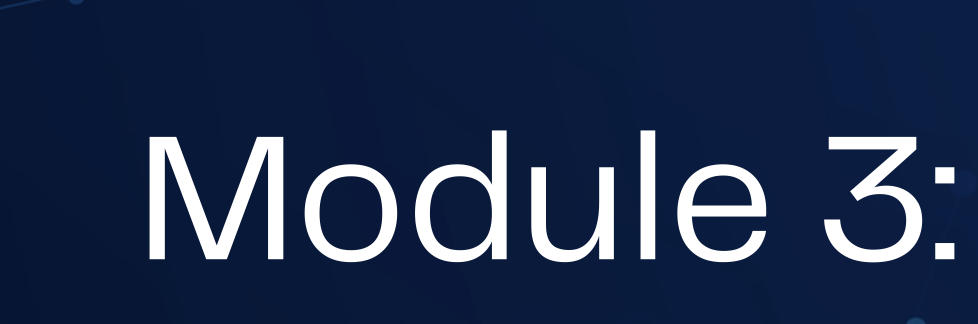

In [ ]:
image_path = '/content/Text_image.webp'   # <-- CHANGE THIS TO YOUR IMAGE PATH

if not os.path.exists(image_path):
    print(f"❌ Image not found at {image_path}. Please upload your image and update the path.")
    # Option: Allow user to upload file
    from google.colab import files
    print("Upload your image now:")
    uploaded = files.upload()
    # Assume first uploaded file is the image
    for fn in uploaded.keys():
        image_path = f"/content/{fn}"
        print(f"✅ Using uploaded file: {image_path}")
        break
else:
    print(f"✅ Image found at {image_path}")

# Load the original image
original_img = Image.open(image_path).convert('RGB')
print("📸 Original Image:")
display(original_img)

# Generate Variations

In [ ]:
variations = []

# Always keep the original as first
variations.append((original_img, "Original"))

# Add variations (you can add/remove or change parameters)
variations.append((rotate_image(original_img, 5), "Rotated +5°"))
variations.append((rotate_image(original_img, -5), "Rotated -5°"))
variations.append((rotate_image(original_img, 15), "Rotated +15°"))
variations.append((skew_image(original_img, 0.2), "Skewed (shear)"))
variations.append((blur_image(original_img, 2), "Blurred"))
variations.append((add_noise(original_img, 30), "With Noise"))
variations.append((adjust_brightness(original_img, 1.8), "Brighter"))
variations.append((adjust_brightness(original_img, 0.5), "Darker"))
variations.append((adjust_contrast(original_img, 2.0), "High Contrast"))
variations.append((resize_image(original_img, 0.5), "Resized 50%"))
variations.append((invert_colors(original_img), "Inverted Colors"))
variations.append((perspective_warp(original_img, 0.03), "Perspective Warp"))

print(f"✅ Created {len(variations)} image variations.")

✅ Created 13 image variations.


# Run OCR on Each Variation and Display


OCR RESULTS ON IMAGE VARIATIONS


--- Variation 1: Original ---


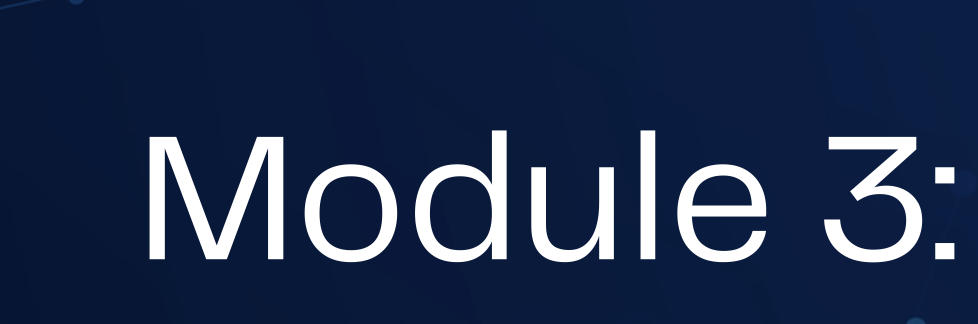

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 2: Rotated +5° ---


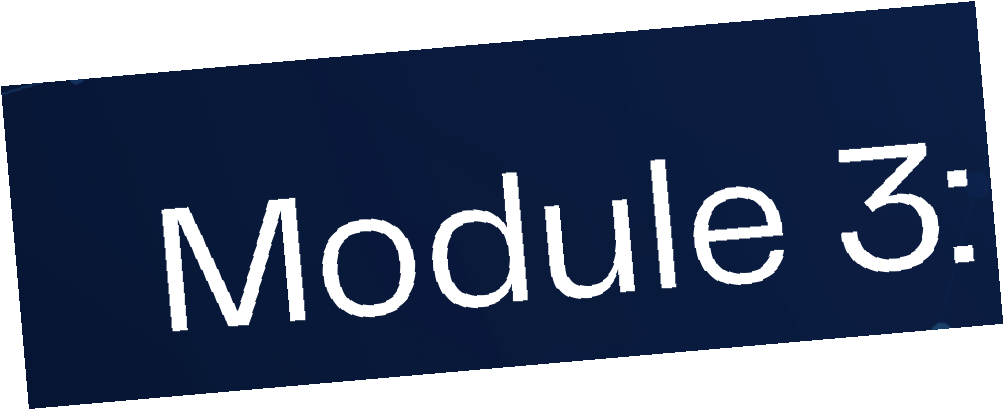

📝 Extracted text: [No text detected]
----------------------------------------

--- Variation 3: Rotated -5° ---


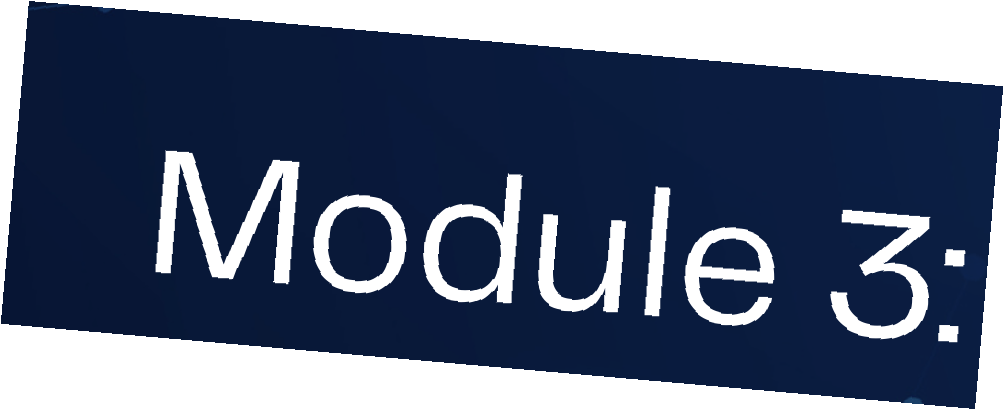

📝 Extracted text: [No text detected]
----------------------------------------

--- Variation 4: Rotated +15° ---


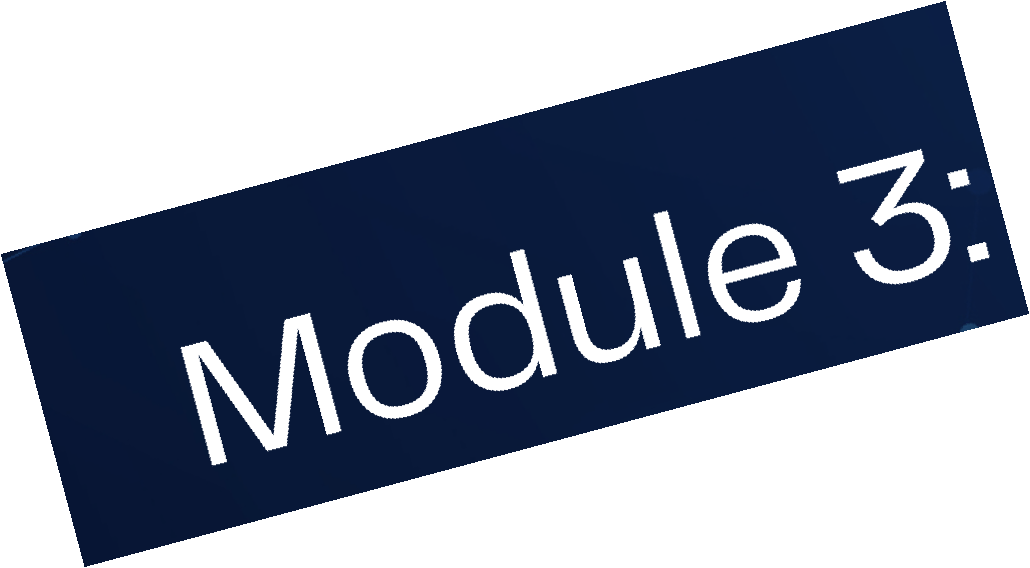

📝 Extracted text: [No text detected]
----------------------------------------

--- Variation 5: Skewed (shear) ---


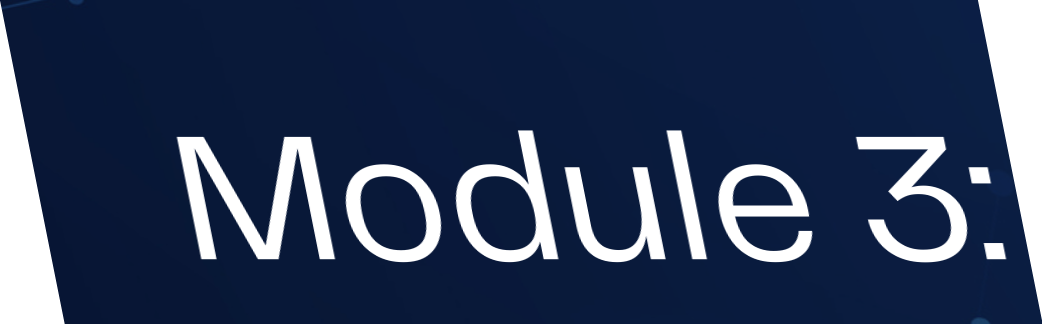

📝 Extracted text: Module a
----------------------------------------

--- Variation 6: Blurred ---


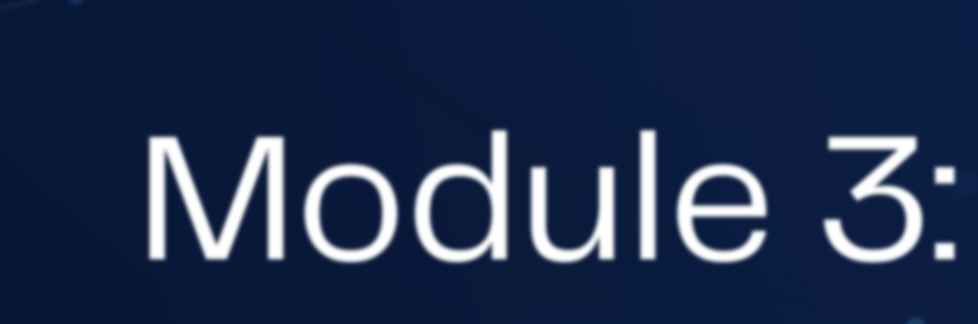

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 7: With Noise ---


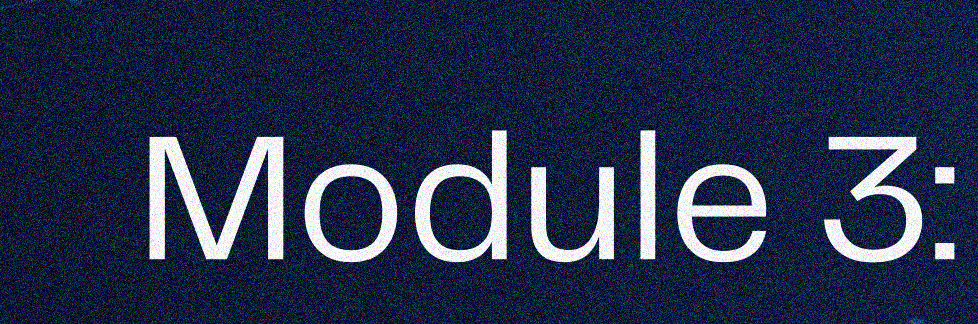

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 8: Brighter ---


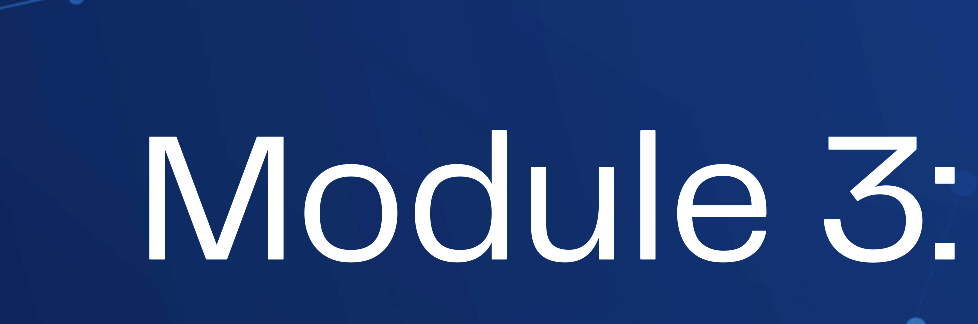

📝 Extracted text: Module SS
----------------------------------------

--- Variation 9: Darker ---


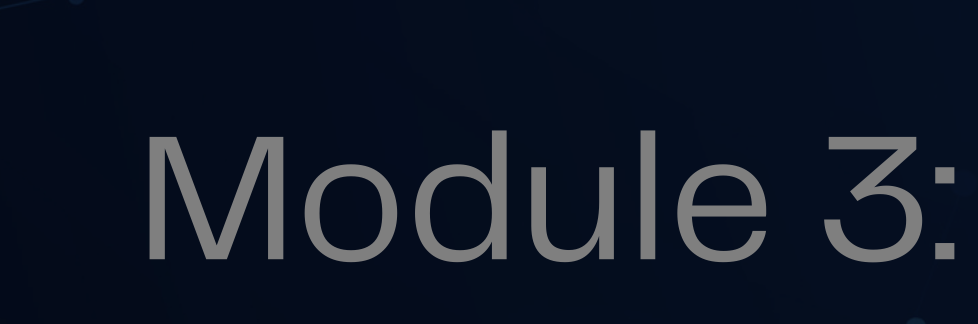

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 10: High Contrast ---


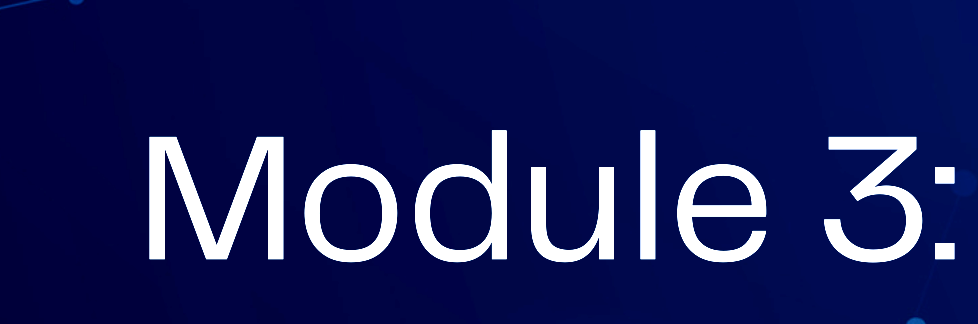

📝 Extracted text: Module oS
----------------------------------------

--- Variation 11: Resized 50% ---


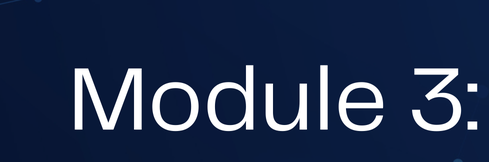

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 12: Inverted Colors ---


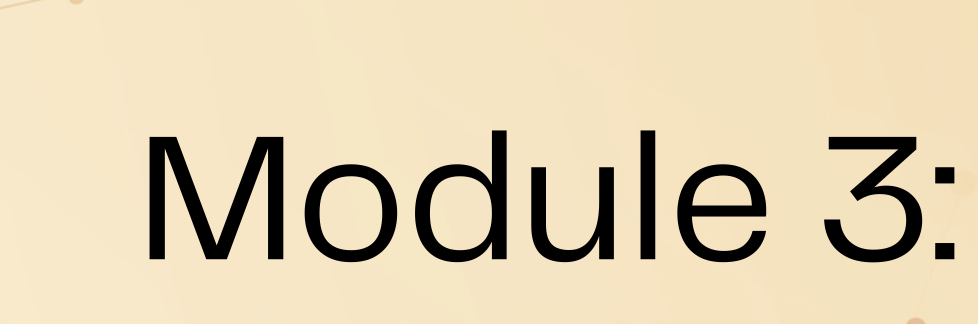

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 13: Perspective Warp ---


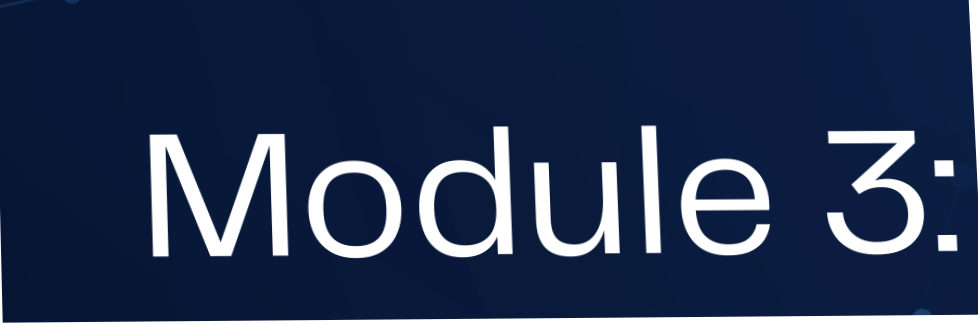

📝 Extracted text: Module 3:
----------------------------------------

✅ Done.


In [ ]:
print("\n" + "="*70)
print("OCR RESULTS ON IMAGE VARIATIONS")
print("="*70 + "\n")

for idx, (img, desc) in enumerate(variations, 1):
    print(f"\n--- Variation {idx}: {desc} ---")

    # Display image
    display(img)

    # Run Tesseract OCR
    try:
        extracted = pytesseract.image_to_string(img)
        extracted = extracted.strip().replace('\n', ' ')
        if extracted == "":
            extracted = "[No text detected]"
        print(f"📝 Extracted text: {extracted}")
    except Exception as e:
        print(f"❌ OCR failed: {e}")

    print("-" * 40)

print("\n✅ Done.")